# 02 - Preprocessing

Prepare the raw brain tumor MRI images for model training by converting them to RGB, resizing them to 224 × 224, and saving the results into `data/processed/`.

## Preprocessing Flow

Raw Images → Convert to RGB → Resize to 224 × 224 → Save to `data/processed/`

Optional augmentation can be added later and stored separately in `data/augmented/`.

In [2]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import seaborn as sns

ImageFile.LOAD_TRUNCATED_IMAGES = True
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

In [6]:
from __future__ import annotations
import os
from pathlib import Path

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    # Adjust this to match your actual cloned repo folder name in Colab
    PROJECT_ROOT = Path('/content/') # Corrected to point to /content
else:
    def find_project_root(start: Path | None = None) -> Path:
        start = start or Path.cwd()
        for candidate in [start, *start.parents]:
            if (candidate / 'data' / 'raw' / 'Training').exists() and (candidate / 'data' / 'raw' / 'Testing').exists():
                return candidate
        raise FileNotFoundError('Could not locate data/raw/Training and data/raw/Testing.')

    PROJECT_ROOT = find_project_root()

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' # Re-added definition
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' # Re-added definition
AUGMENTED_DIR = PROJECT_ROOT / 'data' / 'augmented' # Re-added definition

TRAIN_DIR = RAW_DIR / 'Training' # Changed to use RAW_DIR
TEST_DIR = RAW_DIR / 'Testing' # Changed to use RAW_DIR
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
TARGET_SIZE = (224, 224) # Re-added definition
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

assert TRAIN_DIR.exists() and TEST_DIR.exists(), (
    f"Data not found at {TRAIN_DIR} / {TEST_DIR}. "
    "If in Colab, check your Drive mount and unzip path; if local, check PROJECT_ROOT detection."
)

IN_COLAB, PROJECT_ROOT, TRAIN_DIR, TEST_DIR, RAW_DIR, PROCESSED_DIR, AUGMENTED_DIR, TARGET_SIZE

(True,
 PosixPath('/content'),
 PosixPath('/content/data/raw/Training'),
 PosixPath('/content/data/raw/Testing'),
 PosixPath('/content/data/raw'),
 PosixPath('/content/data/processed'),
 PosixPath('/content/data/augmented'),
 (224, 224))

## Data Setup

To resolve the `AssertionError`, we need to ensure the raw data is available in the Colab environment at the expected path. This involves mounting Google Drive and unzipping the `raw_data.zip` file.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Create the target directory if it doesn't exist
!mkdir -p /content/data/raw/

# Unzip your data into the /content/data/raw/ directory
# Assuming 'raw_data.zip' is in your Google Drive's root. Adjust path if necessary.
!unzip -q "/content/drive/MyDrive/raw_data.zip" -d /content/data/raw/

print("Data unzipped to /content/data/raw/")

Data unzipped to /content/data/raw/


In [9]:
def collect_images(root_dir):
    rows = []
    for split_name in ['Training', 'Testing']:
        split_dir = root_dir / split_name
        if not split_dir.exists():
            continue
        for class_name in CLASSES:
            class_dir = split_dir / class_name
            if not class_dir.exists():
                continue
            for file_path in sorted(class_dir.rglob('*')):
                if file_path.suffix.lower() in IMAGE_EXTENSIONS:
                    rows.append({
                        'split': split_name,
                        'class': class_name,
                        'path': file_path
                    })
    return pd.DataFrame(rows)

raw_df = collect_images(RAW_DIR)
raw_df.head()

,split,class,path
0,Training,glioma,/content/data/raw/Training/glioma/Tr-gl_1.jpg
1,Training,glioma,/content/data/raw/Training/glioma/Tr-gl_10.jpg
2,Training,glioma,/content/data/raw/Training/glioma/Tr-gl_100.jpg
3,Training,glioma,/content/data/raw/Training/glioma/Tr-gl_1000.jpg
4,Training,glioma,/content/data/raw/Training/glioma/Tr-gl_1001.jpg


In [10]:
def preprocess_image(image_path, target_size=TARGET_SIZE):
    with Image.open(image_path) as image:
        image = image.convert('RGB')
        image = image.resize(target_size, Image.Resampling.LANCZOS)
        return image

def save_preprocessed_images(source_df, output_root):
    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    records = []
    for _, row in source_df.iterrows():
        source_path = Path(row['path'])
        destination_dir = output_root / row['split'] / row['class']
        destination_dir.mkdir(parents=True, exist_ok=True)

        destination_path = destination_dir / source_path.name
        try:
            processed_image = preprocess_image(source_path)
            processed_image.save(destination_path)
            records.append({
                'source_path': str(source_path),
                'destination_path': str(destination_path),
                'split': row['split'],
                'class': row['class'],
                'status': 'saved'
            })
        except Exception as error:
            records.append({
                'source_path': str(source_path),
                'destination_path': str(destination_path),
                'split': row['split'],
                'class': row['class'],
                'status': f'failed: {error}'
            })

    return pd.DataFrame(records)

In [11]:
processed_df = save_preprocessed_images(raw_df, PROCESSED_DIR)
processed_df['status'].value_counts()

,count
status,
saved,7200


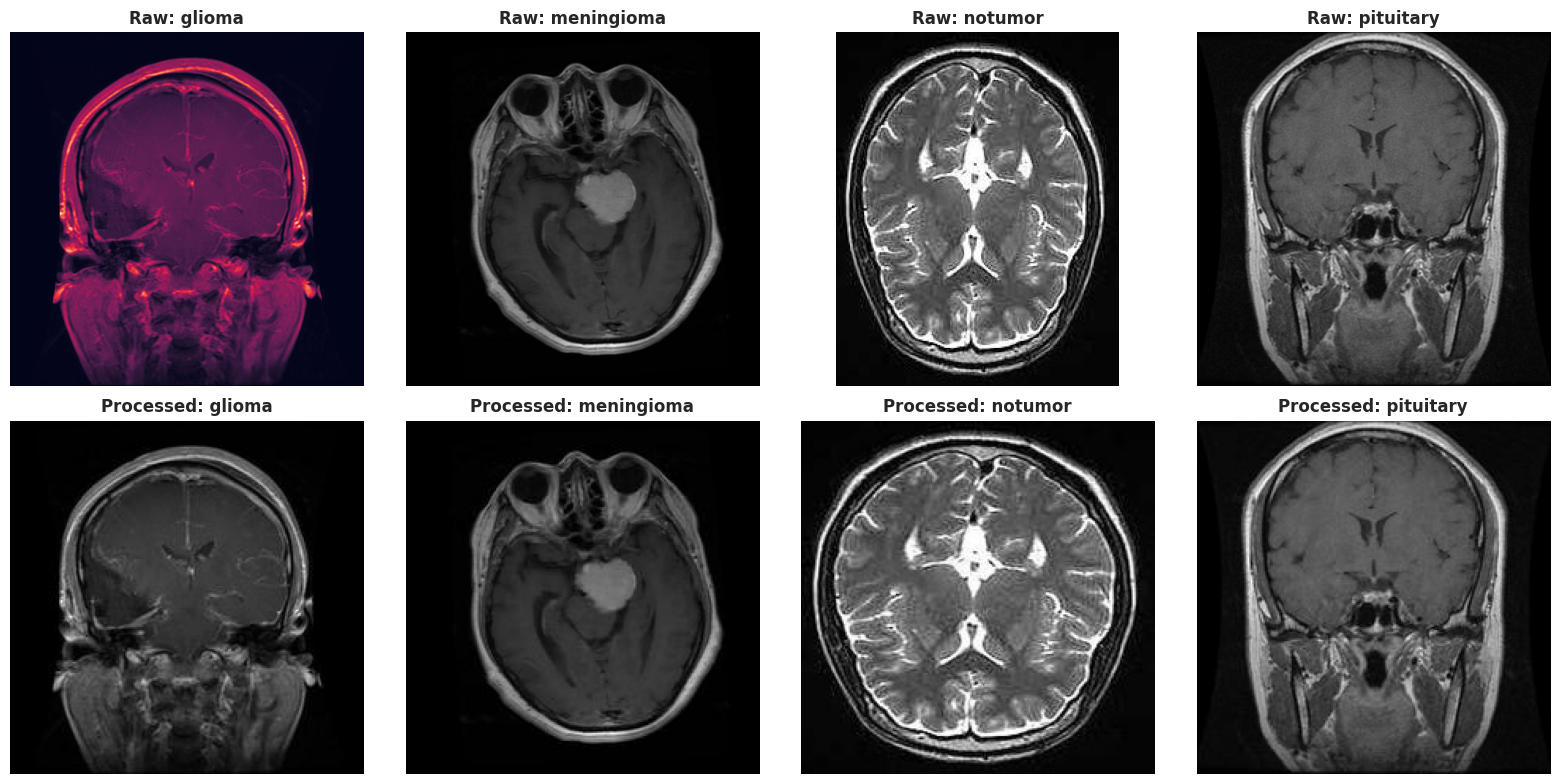

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_classes = CLASSES
for col_index, class_name in enumerate(sample_classes):
    class_rows = raw_df[raw_df['class'] == class_name].head(1)
    if class_rows.empty:
        continue
    source_path = class_rows.iloc[0]['path']
    processed_path = Path(PROCESSED_DIR) / class_rows.iloc[0]['split'] / class_name / source_path.name

    with Image.open(source_path) as before_image:
        axes[0, col_index].imshow(before_image)
        axes[0, col_index].set_title(f'Raw: {class_name}')
        axes[0, col_index].axis('off')

    with Image.open(processed_path) as after_image:
        axes[1, col_index].imshow(after_image)
        axes[1, col_index].set_title(f'Processed: {class_name}')
        axes[1, col_index].axis('off')

plt.tight_layout()
plt.show()